In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [3]:
baseline_meanlists = {}
baseline_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data_compute_scaling_study"):
    dlist = []
    
    for csvfile in os.listdir(f"data_compute_scaling_study/{checkpoint}/baseline/"):
        data = pd.read_csv(f"data_compute_scaling_study/{checkpoint}/baseline/{csvfile}")
    
        dlist.append(data["TRA"].to_list())
        baseline_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    baseline_meanlists[checkpoint] = meanlist

In [4]:
meanlists = {}
treatment_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data_compute_scaling_study"):
    dlist = []
    
    for csvfile in os.listdir(f"data_compute_scaling_study/{checkpoint}/witheffects/"):
        data = pd.read_csv(f"data_compute_scaling_study/{checkpoint}/witheffects/{csvfile}")
    
        dlist.append(data["TRA"].to_list())
        treatment_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    meanlists[checkpoint] = meanlist

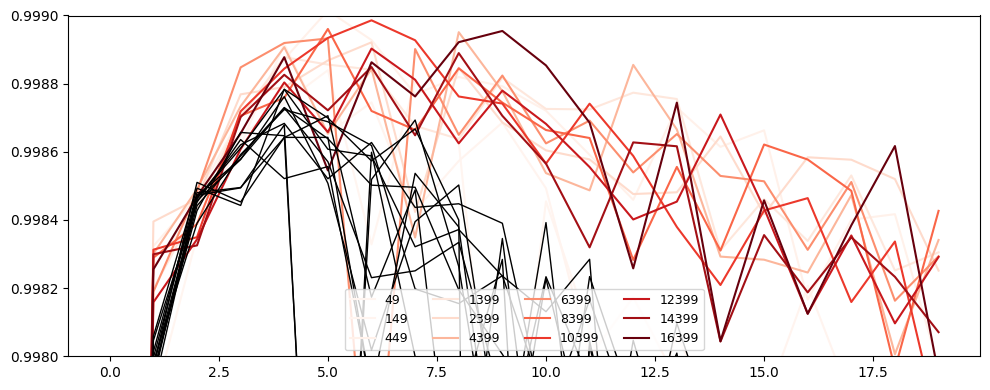

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Ensure numeric sorting of keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for color mapping
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.Reds

# Plot main curves with increasing red intensity
for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(meanlists[k][:20], label=str(k), color=color)

# Plot baselines in black (no legend entries)
for ml in baseline_meanlists.values():
    plt.plot(ml[:20], color='black', linewidth=1)

plt.ylim(0.998, 0.999)
plt.legend(loc="lower center", ncol=4, fontsize=9)
plt.tight_layout()

plt.savefig("monochromatic_compute_scaling.pdf")


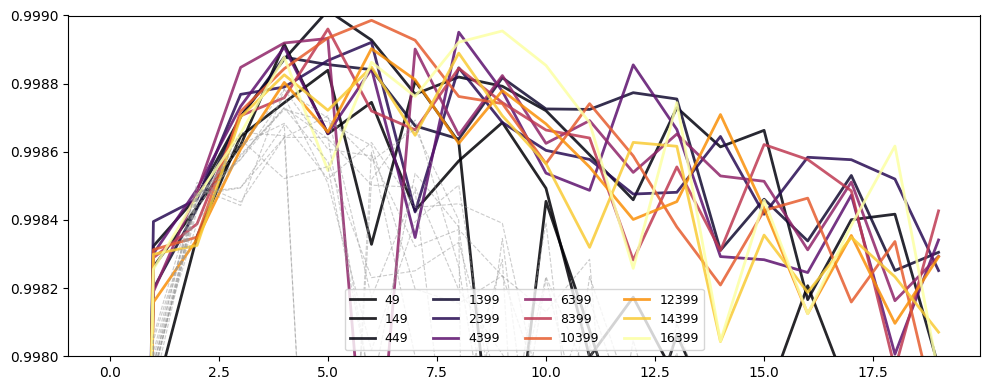

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Numerically sort keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for colormap scaling
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(
        meanlists[k][:20],
        label=str(k),
        color=color,
        linewidth=2.0,
        alpha=0.85
    )


# Plot baselines as faint reference curves
for ml in baseline_meanlists.values():
    plt.plot(
        ml[:20],
        linestyle="--",
        color="0.6",      # neutral gray
        linewidth=0.8,
        alpha=0.5,
        label="_nolegend_"
    )


plt.ylim(0.998, 0.999)
plt.legend(loc="lower center", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


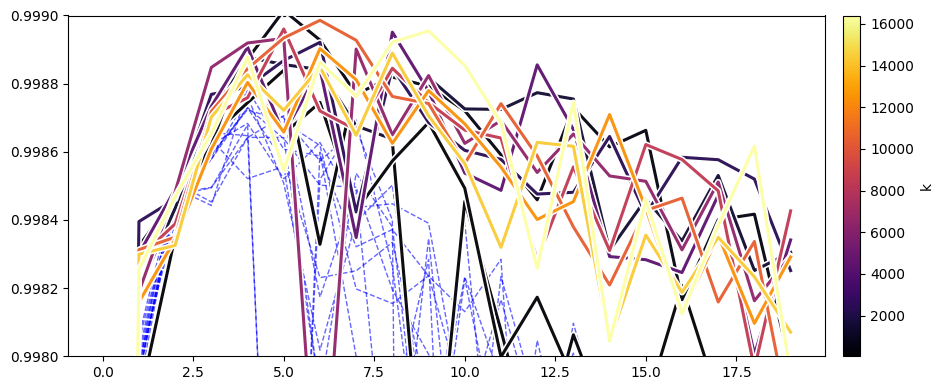

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 4))

sorted_keys = sorted(meanlists.keys(), key=int)
key_values = [int(k) for k in sorted_keys]

norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

# Colored series with white halo
for k in sorted_keys:
    color = cmap(norm(int(k)))
    (line,) = ax.plot(
        meanlists[k][:20],
        color=color,
        linewidth=2.2,
        alpha=0.95,
        zorder=int(k),
    )
    line.set_path_effects([
        pe.Stroke(linewidth=4.5, foreground="white"),
        pe.Normal()
    ])

# Baselines
for ml in baseline_meanlists.values():
    ax.plot(ml[:20], "--", color="blue", linewidth=1, alpha=0.6, zorder=0)

ax.set_ylim(0.998, 0.999)

# Colorbar keyed to k
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("k")

fig.tight_layout()
plt.show

plt.savefig("compute_scaling_fluo_draft.pdf")

[8399, 6399, 49, 449, 4399, 2399, 16399, 149, 14399, 1399, 12399, 10399]

Slope (m):     1.58738e-09
Intercept (b): 0.999027
R²:            0.00988518


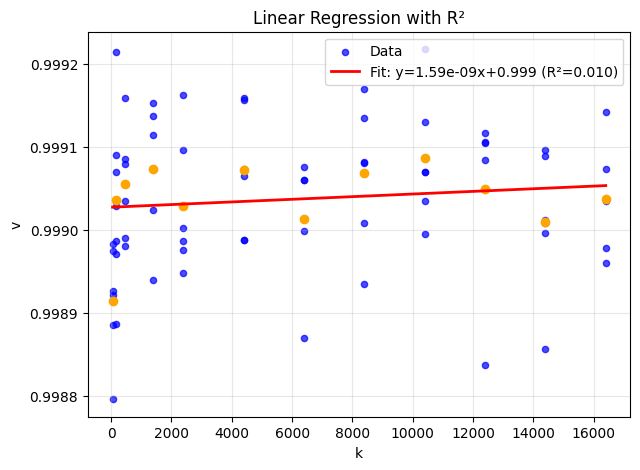

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- Flatten baseline_compute_max_map into x/y arrays ---
x = []
y = []
means = []

for k, l in treatment_compute_max_map.items():
    for v in l:
        x.append(k)
        y.append(v)
    means.append(sum(l) / len(l))

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)


if x.size < 2:
    raise ValueError("Need at least 2 (k, v) points to fit a regression.")

# --- Linear regression: y = m*x + b ---
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# --- R^2 ---
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print(f"Slope (m):     {m:.6g}")
print(f"Intercept (b): {b:.6g}")
print(f"R²:            {r_squared:.6g}")

# --- Plot points + regression line ---
plt.figure(figsize=(7, 5))
plt.scatter(x, y, c="blue", s=20, alpha=0.7, label="Data")

# Smooth line across the x-range
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, c="red", linewidth=2, label=f"Fit: y={m:.3g}x+{b:.3g} (R²={r_squared:.3f})")

plt.scatter([x for x in treatment_compute_max_map.keys()], means, color='orange')

plt.xlabel("k")
plt.ylabel("v")
plt.title("Linear Regression with R²")
plt.grid(True, alpha=0.3)
plt.legend()


plt.savefig("compute_scaling_full.pdf")

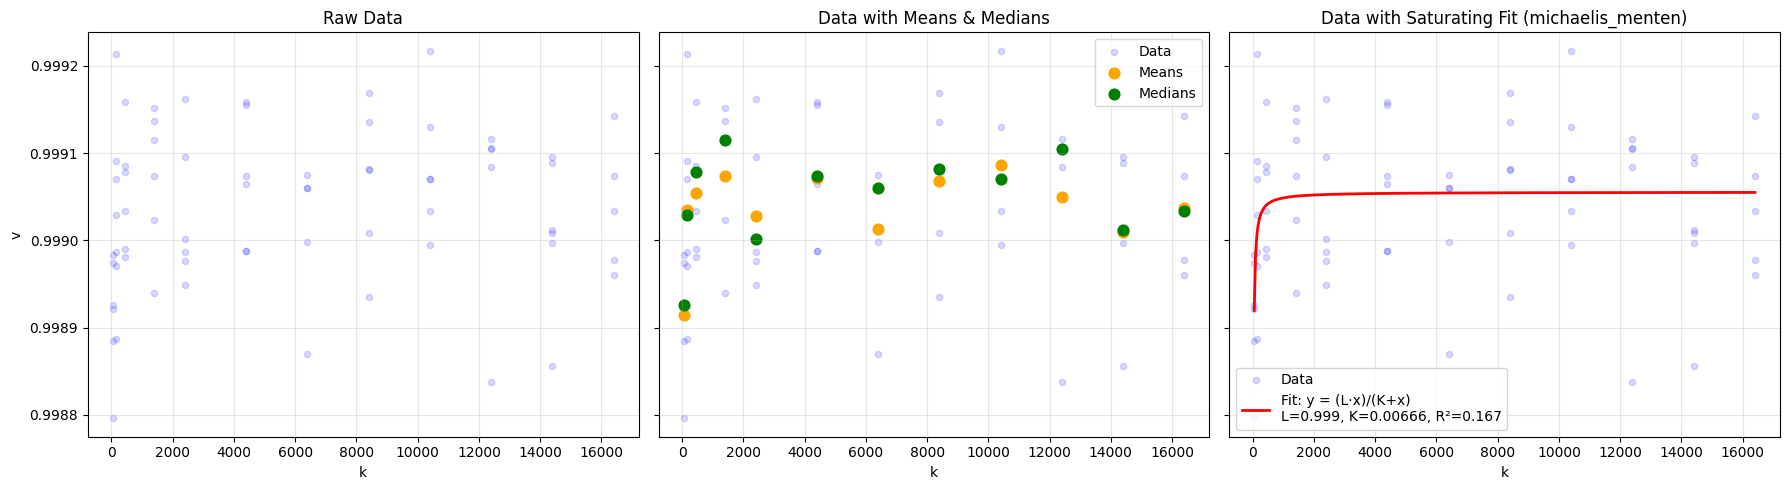

In [30]:
# --- Three side-by-side plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# --- 1) Raw data only ---
axes[0].scatter(x, y, c="blue", s=20, alpha=0.15)
axes[0].set_title("Raw Data")
axes[0].set_xlabel("k")
axes[0].set_ylabel("v")
axes[0].grid(True, alpha=0.3)

# --- 2) Data + means + medians ---
axes[1].scatter(x, y, c="blue", s=20, alpha=0.15, label="Data")
axes[1].scatter(keys, means, c="orange", s=60, label="Means")
axes[1].scatter(keys, medians, c="green", s=60, label="Medians")
axes[1].set_title("Data with Means & Medians")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# --- 3) Data + regression curve ---
axes[2].scatter(x, y, c="blue", s=20, alpha=0.15, label="Data")

x_line = np.linspace(x.min(), x.max(), 400)
y_line = michaelis_menten(x_line, L, K)

axes[2].plot(
    x_line,
    y_line,
    c="red",
    linewidth=2,
    label=f"Fit: y = (L·x)/(K+x)\nL={L:.3g}, K={K:.3g}, R²={r_squared:.3f}"
)

axes[2].set_title("Data with Saturating Fit (michaelis_menten)")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig("compute_scaling_michaelis_menten.pdf")
plt.show()


Regression k < 5000
  slope:     7.57873e-08
  intercept: 0.998982
  R²:        0.169061

Regression k > 5000
  slope:     -8.00589e-10
  intercept: 0.999054
  R²:        0.00195783


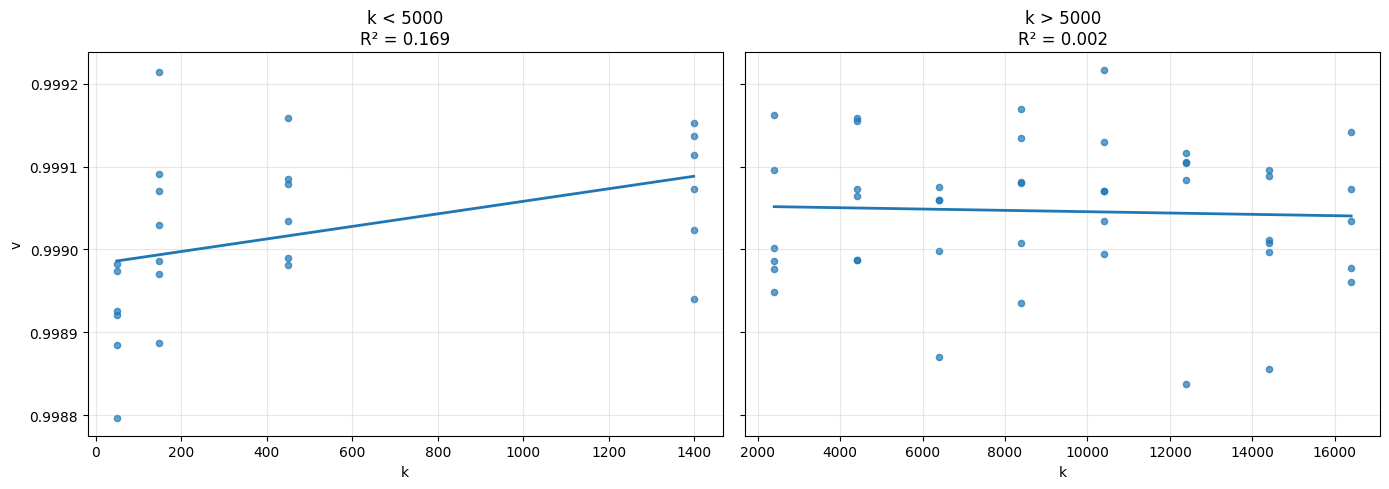

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def regression_from_map(baseline_compute_max_map, condition):
    x, y = [], []
    for k, l in treatment_compute_max_map.items():
        if condition(k):
            for v in l:
                x.append(k)
                y.append(v)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.size < 2:
        return None, None, None, None, None

    m, b = np.polyfit(x, y, 1)
    y_pred = m * x + b

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return x, y, m, b, r2


# --- Compute both regressions ---
x1, y1, m1, b1, r2_1 = regression_from_map(
    baseline_compute_max_map, lambda k: k < 2000
)

x2, y2, m2, b2, r2_2 = regression_from_map(
    baseline_compute_max_map, lambda k: k > 2000
)

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left plot: k < 2000
axes[0].scatter(x1, y1, s=20, alpha=0.7)
x_line = np.linspace(x1.min(), x1.max(), 200)
axes[0].plot(x_line, m1 * x_line + b1, linewidth=2)
axes[0].set_title(f"k < 5000\nR² = {r2_1:.3f}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("v")
axes[0].grid(True, alpha=0.3)

# Right plot: k > 5000
axes[1].scatter(x2, y2, s=20, alpha=0.7)
x_line = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(x_line, m2 * x_line + b2, linewidth=2)
axes[1].set_title(f"k > 5000\nR² = {r2_2:.3f}")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# --- Print numeric summaries ---
print("Regression k < 5000")
print(f"  slope:     {m1:.6g}")
print(f"  intercept: {b1:.6g}")
print(f"  R²:        {r2_1:.6g}\n")

print("Regression k > 5000")
print(f"  slope:     {m2:.6g}")
print(f"  intercept: {b2:.6g}")
print(f"  R²:        {r2_2:.6g}")


plt.savefig("compute_scaling_split_POSTHOC.pdf")